 Dataset chargé : 510,530 lignes × 14 colonnes
 Features : ['PRN', 'DO', 'PD', 'RX', 'TOW', 'CP', 'EC', 'LC', 'PC', 'PIP', 'PQP', 'TCD', 'CN0', 'Output']
  Mapping M/C/P défini
 Dimension M : 4 features
 Dimension C : 6 features
 Dimension P : 3 features
 Ignorées    : 1 colonnes
 Tableau de mapping M/C/P — GPS Spoofing :

Feature Dimension                                                                                                      Justification
    PRN         C              Pseudo-Random Noise code — identifiant du satellite — composant canal satellite ciblé par le spoofing
     EC         C       Early-minus-Late Correlator — corrélateur du récepteur — composant discriminateur de phase du récepteur GNSS
     LC         C                             Late Correlator — corrélateur retardé — composant de suivi du signal dans le récepteur
     PC         C                        Prompt Correlator — corrélateur central — composant principal de démodulation du signal GPS
    PIP   

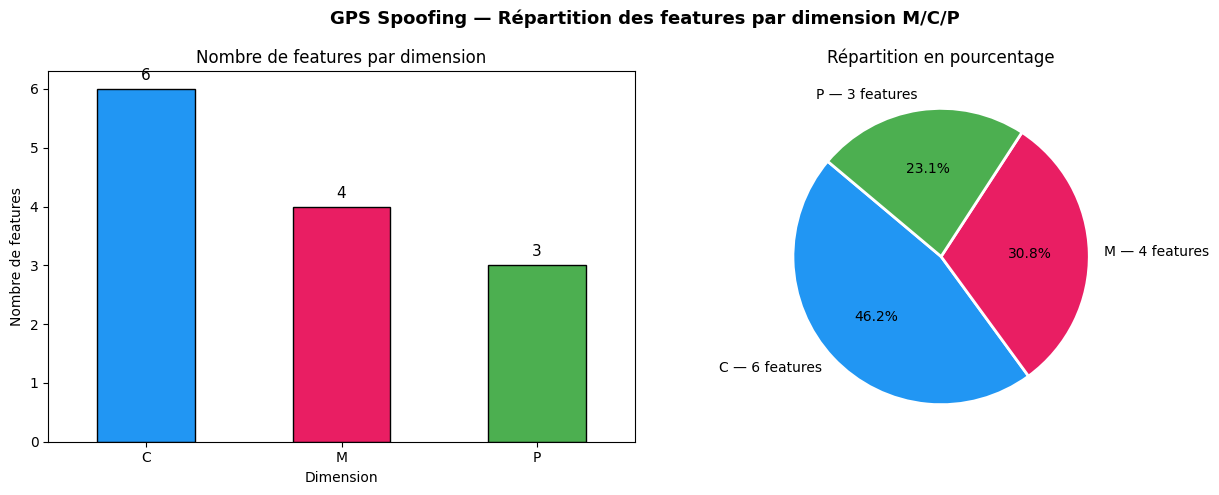

 Features M (4) : ['DO', 'PD', 'CP', 'TCD']

 Features C (6) : ['PRN', 'EC', 'LC', 'PC', 'PIP', 'PQP']

 Features P (3) : ['RX', 'TOW', 'CN0']

 M présentes dans df2 : 4/4
   C présentes dans df2 : 6/6
   P présentes dans df2 : 3/3


In [ ]:
# ============================================================
# NOTEBOOK : Mapping M/C/P — GPS Spoofing
# Dataset  : Signal-level GPS attack captures
# ============================================================

# ────────────────────────────────────────
# 1. IMPORTATION DES LIBRAIRIES
# ────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ────────────────────────────────────────
# 2. CHARGEMENT DU DATASET
# ────────────────────────────────────────
PATH = r"C:\Drone_Attack_Similarity_Project\DATASET\GPS_Spoofing"

# On utilise df2 (version simplifiée) comme référence pour le mapping
df2 = pd.read_csv(os.path.join(PATH, "GPS_Simplified.csv"))

print(f" Dataset chargé : {df2.shape[0]:,} lignes × {df2.shape[1]} colonnes")
print(f" Features : {df2.columns.tolist()}")


# ────────────────────────────────────────
# 3. DÉFINITION DU MAPPING M/C/P
# ────────────────────────────────────────

mapping_gps = {

    # ── M : MÉCANISME D'ATTAQUE ──────────────────────────────
    # Features décrivant COMMENT l'attaque GPS agit
    # Le spoofing GPS injecte de faux signaux pour tromper
    # le récepteur — ces features révèlent cette injection

    'DO'  : ('M', 'Doppler Offset — décalage de fréquence Doppler — '
                  'une valeur anormale révèle un faux signal injecté'),
    'PD'  : ('M', 'Pseudorange Deviation — déviation de la pseudodistance — '
                  'écart entre distance réelle et mesurée par le faux signal'),
    'CP'  : ('M', 'Carrier Phase — phase de la porteuse — '
                  'discontinuité révèle injection d\'un signal spoofé'),
    'TCD' : ('M', 'Time Correlation Deviation — déviation temporelle — '
                  'mécanisme de décalage horloge du signal GPS falsifié'),

    # ── C : COMPOSANT CIBLÉ ──────────────────────────────────
    # Features décrivant QUEL composant GPS est affecté
    # Le spoofing cible le récepteur GNSS et ses canaux satellites

    'PRN' : ('C', 'Pseudo-Random Noise code — identifiant du satellite — '
                  'composant canal satellite ciblé par le spoofing'),
    'EC'  : ('C', 'Early-minus-Late Correlator — corrélateur du récepteur — '
                  'composant discriminateur de phase du récepteur GNSS'),
    'LC'  : ('C', 'Late Correlator — corrélateur retardé — '
                  'composant de suivi du signal dans le récepteur'),
    'PC'  : ('C', 'Prompt Correlator — corrélateur central — '
                  'composant principal de démodulation du signal GPS'),
    'PIP' : ('C', 'Power In Phase — puissance en phase — '
                  'composant canal I du récepteur GNSS ciblé'),
    'PQP' : ('C', 'Power Quadrature Phase — puissance en quadrature — '
                  'composant canal Q du récepteur GNSS ciblé'),

    # ── P : PARAMÈTRE D'EXÉCUTION ────────────────────────────
    # Features décrivant les VALEURS MESURABLES
    # qui paramétrisent l'intensité du signal spoofé

    'RX'  : ('P', 'Reception Time — temps de réception — '
                  'paramètre temporel du signal reçu'),
    'TOW' : ('P', 'Time Of Week — temps GPS de la semaine — '
                  'paramètre de synchronisation temporelle falsifiée'),
    'CN0' : ('P', 'Carrier-to-Noise ratio — rapport signal/bruit — '
                  'paramètre d\'intensité du signal spoofé vs authentique'),

    # ── IGNORÉE ───────────────────────────────────────────────
    'Output' : ('—', 'Label de classe — variable cible, pas une feature d\'attaque'),
}

print("  Mapping M/C/P défini")
print(f" Dimension M : {sum(1 for v in mapping_gps.values() if v[0]=='M')} features")
print(f" Dimension C : {sum(1 for v in mapping_gps.values() if v[0]=='C')} features")
print(f" Dimension P : {sum(1 for v in mapping_gps.values() if v[0]=='P')} features")
print(f" Ignorées    : {sum(1 for v in mapping_gps.values() if v[0]=='—')} colonnes")

# ────────────────────────────────────────
# 4. CRÉATION DU TABLEAU DE MAPPING
# ────────────────────────────────────────
rows = []
for feature, (dimension, justification) in mapping_gps.items():
    rows.append({
        'Feature'      : feature,
        'Dimension'    : dimension,
        'Justification': justification
    })

mapping_df = pd.DataFrame(rows).sort_values('Dimension')

print(" Tableau de mapping M/C/P — GPS Spoofing :\n")
print(mapping_df.to_string(index=False))

# ────────────────────────────────────────
# 5. VISUALISATION DU MAPPING
# ────────────────────────────────────────
mapping_plot = mapping_df[mapping_df['Dimension'] != '—']
counts = mapping_plot['Dimension'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("GPS Spoofing — Répartition des features par dimension M/C/P",
fontsize=13, fontweight='bold')

colors     = {'M': '#E91E63', 'C': '#2196F3', 'P': '#4CAF50'}
color_list = [colors[d] for d in counts.index]

# Barplot
counts.plot(kind='bar', ax=axes[0], color=color_list,
            edgecolor='black', width=0.5)
axes[0].set_title("Nombre de features par dimension")
axes[0].set_xlabel("Dimension")
axes[0].set_ylabel("Nombre de features")
axes[0].tick_params(axis='x', rotation=0)
for bar, val in zip(axes[0].patches, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.1,
                 str(val), ha='center', va='bottom', fontsize=11)

# Pie chart
axes[1].pie(counts.values,labels=[f"{d} — {v} features"
                    for d, v in zip(counts.index, counts.values)],
            autopct='%1.1f%%',
            colors=color_list,
            startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title("Répartition en pourcentage")

plt.tight_layout()
plt.savefig("GPS_mapping_MCP.png", dpi=150, bbox_inches='tight')
plt.show()


# ────────────────────────────────────────
# 6. EXTRACTION DES FEATURES PAR DIMENSION
# ────────────────────────────────────────
features_M = mapping_plot[mapping_plot['Dimension'] == 'M']['Feature'].tolist()
features_C = mapping_plot[mapping_plot['Dimension'] == 'C']['Feature'].tolist()
features_P = mapping_plot[mapping_plot['Dimension'] == 'P']['Feature'].tolist()

print(f" Features M ({len(features_M)}) : {features_M}")
print(f"\n Features C ({len(features_C)}) : {features_C}")
print(f"\n Features P ({len(features_P)}) : {features_P}")

features_M_ok = [f for f in features_M if f in df2.columns]
features_C_ok = [f for f in features_C if f in df2.columns]
features_P_ok = [f for f in features_P if f in df2.columns]

print(f"\n M présentes dans df2 : {len(features_M_ok)}/{len(features_M)}")
print(f"   C présentes dans df2 : {len(features_C_ok)}/{len(features_C)}")
print(f"   P présentes dans df2 : {len(features_P_ok)}/{len(features_P)}")
